In [43]:
using LinearAlgebra
using Random

Random.seed!(42)

n = 100
ratio = 15
eps = 1e-3
max_iter = 10000

function generate_system(n, ratio)
    A = rand(-10.0:100.0, n, n)
    for i in 1:n
        S = sum(abs, A[i, :]) - abs(A[i, i])
        A[i, i] = round(ratio * S, digits=2)
    end
    return A
end

function simple_iteration(A, b, eps, max_iter)
    n = length(b)
    P = zeros(n, n)
    g = zeros(n)
    for i in 1:n
        g[i] = b[i] / A[i, i]

        for j in 1:n
            if i != j
                P[i, j] = -A[i, j] / A[i, i]
            end
        end
    end

    P_norm = opnorm(P, Inf)
    println("Норма P = ", P_norm)

    if P_norm < 1
        println("Условие сходимости ||P|| < 1 выполнено")
    else
        println("Условие сходимости ||P|| < 1 не выполнено")
    end

    x_prev = zeros(n)
    history = Vector{Vector{Float64}}()
    push!(history, copy(x_prev))

    for k in 1:max_iter
        x = P * x_prev + g
        push!(history, copy(x))
        delta_x = x - x_prev
        err = norm(delta_x)
        if err <= eps
            return x, k, err, history
        end

        x_prev = x
    end

    error("Метод не сошелся за $max_iter итераций")
end

A = generate_system(n, ratio)
x_exact = ones(n)
b = A * x_exact
x, iterations, err, history = simple_iteration(A, b, eps, max_iter)

println("КДП = ", ratio)
println("Количество итераций: ", iterations)
println("Полученный x: ", x)
println("delta_x^(k): ", err)
println("Норма разницы: ", norm(x - x_exact))

Норма P = 0.06666666666666678
Условие сходимости ||P|| < 1 выполнено
КДП = 15
Количество итераций: 5
Полученный x: [1.0000011893406964, 1.000001196727578, 1.0000011607906079, 1.0000011870505725, 1.0000011760274714, 1.0000011888158105, 1.000001183942971, 1.0000011811292095, 1.0000011870108012, 1.0000011865985017, 1.000001182606706, 1.0000011721975957, 1.0000011980741734, 1.0000011906590738, 1.0000011878406931, 1.0000011877928727, 1.000001169551867, 1.0000011930618788, 1.0000011978614078, 1.0000011577918504, 1.000001188990867, 1.0000011780803113, 1.0000011903012156, 1.0000011842969803, 1.0000011847120223, 1.000001182813688, 1.000001181975499, 1.0000011924359222, 1.000001198734819, 1.0000011913130078, 1.0000011699465354, 1.0000011855765947, 1.0000011804958677, 1.0000011697712665, 1.0000011834020353, 1.0000011905431632, 1.0000011812807954, 1.000001181893232, 1.0000011982612493, 1.000001187475695, 1.000001191392941, 1.0000011931675121, 1.0000011885964537, 1.0000012020746127, 1.0000011790978

In [44]:
function seidel(A, b, eps, max_iter)
    n = length(b)
    x_prev = zeros(n)
    for k in 1:max_iter
        x = copy(x_prev)
        for i in 1:n
            sum1 = 0.0
            sum2 = 0.0
            for j in 1:i-1
                sum1 = sum1 + A[i, j] * x[j]
            end
            for j in i+1:n
                sum2 = sum2 + A[i, j] * x_prev[j]
            end
            x[i] = (b[i] - sum1 - sum2) / A[i, i]
        end
        delta_x = x - x_prev
        err = norm(delta_x)
        if err <= eps
            return x, k, err
        end
        x_prev = x
    end
    error("Метод не сошелся за $max_iter итераций")
end

x_seidel, iterations_seidel, err_seidel = seidel(A, b, eps, max_iter)

println("КДП = ", ratio)
println("Количество итераций: ", iterations_seidel)
println("Полученный x: ", x_seidel)
println("delta_x^(k): ", err_seidel)
println("Норма разницы: ", norm(x_seidel - x_exact))

КДП = 15
Количество итераций: 4
Полученный x: [0.9999994041703071, 0.9999994360635128, 0.9999995411861258, 0.9999995083487475, 0.9999995739204358, 0.9999996150166237, 0.9999995879777889, 0.9999997166009594, 0.9999996382643347, 0.9999996977571577, 0.99999966184975, 0.999999695112235, 0.999999756083519, 0.9999997271396819, 0.9999997846365778, 0.9999998079517948, 0.9999997603428008, 0.9999997971401355, 0.9999998297311742, 0.9999998602523811, 0.9999998238744784, 0.9999998643717294, 0.9999998534026041, 0.9999998946092847, 0.9999999140543042, 0.9999999074823519, 0.9999998926982692, 0.9999999277917427, 0.9999999442566776, 0.9999999449804313, 0.9999999376085875, 0.9999999583597733, 0.9999999300655603, 0.9999999480338388, 0.9999999551740297, 0.999999979735521, 0.9999999789321156, 0.9999999907261052, 0.9999999924603562, 0.9999999895439299, 0.9999999834242825, 0.9999999812105509, 0.9999999991426345, 0.9999999990973535, 0.9999999985033278, 1.0000000100971809, 1.0000000097879738, 1.000000009494679,

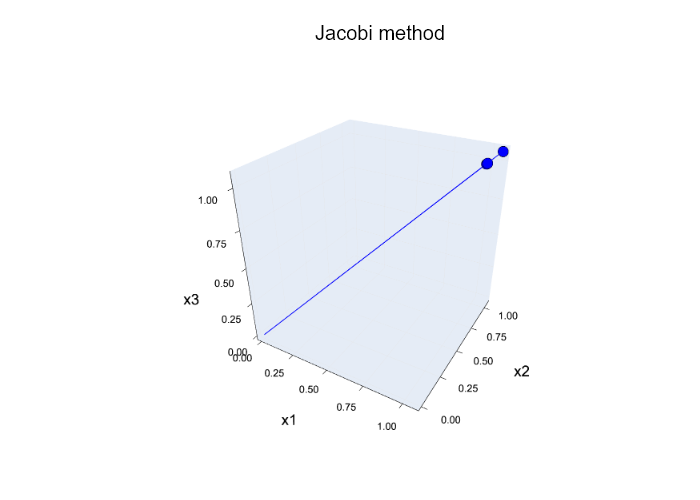

In [50]:
using Plots
plotly()

p = plot(
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "x3",
    title = "Jacobi method",
    legend = false
)

iteration_count = length(history) - 1

for k in 1:iteration_count
    v = history[k + 1]
    hover_text = [
        "x($k)<br>
        x = $(round(v[1], digits=6))<br>
        y = $(round(v[2], digits=6))<br>
        z = $(round(v[3], digits=6))"
    ]

    plot3d!(
        p,
        [0.0, v[1]],
        [0.0, v[2]],
        [0.0, v[3]],
        linewidth = 1.5,
        color = :blue,
        label = ""
    )

    if k == iteration_count
        scatter!(
            p,
            [v[1]],
            [v[2]],
            [v[3]],
            markersize = 3,
            color = :green,
            hover = hover_text,
            label = ""
        )
    else
        scatter!(
            p,
            [v[1]],
            [v[2]],
            [v[3]],
            markersize = 3,
            color = :blue,
            hover = hover_text,
            label = ""
        )
    end
end

display(p)